In [186]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/raw/Medical_appointment_data.csv")

# Basic info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

df.head()

Shape: (109593, 26)

Columns:
 Index(['specialty', 'appointment_time', 'gender', 'no_show', 'disability',
       'place', 'appointment_shift', 'age', 'under_12_years_old',
       'over_60_years_old', 'patient_needs_companion', 'average_temp_day',
       'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before',
       'storm_day_before', 'rain_intensity', 'heat_intensity',
       'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism',
       'Handcap', 'Scholarship', 'SMS_received'],
      dtype='object')

Data Types:
 specialty                       object
appointment_time                 int64
gender                          object
no_show                         object
disability                      object
place                           object
appointment_shift               object
age                            float64
under_12_years_old               int64
over_60_years_old                int64
patient_needs_companion          int64
average_temp_day

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0


In [187]:
# Check target variable distribution
print(df['no_show'].value_counts())
print("\nPercentage:\n", df['no_show'].value_counts(normalize=True) * 100)

# Check time column
print("\nDate column type:", df['appointment_date_continuous'].dtype)


# Convert to datetime
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])

# Check date range
print("\nMin date:", df['appointment_date_continuous'].min())
print("Max date:", df['appointment_date_continuous'].max())

no_show
no     74761
yes    34832
Name: count, dtype: int64

Percentage:
 no_show
no     68.216948
yes    31.783052
Name: proportion, dtype: float64

Date column type: object

Min date: 2020-01-01 00:00:00
Max date: 2021-05-12 00:00:00


In [188]:
# Sort data by date (VERY IMPORTANT)
df = df.sort_values(by='appointment_date_continuous')

# Create split date
split_date = '2021-01-01'

# Train data (past)
train_df = df[df['appointment_date_continuous'] < split_date]

# Test data (future)
test_df = df[df['appointment_date_continuous'] >= split_date]

# Check shapes
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Verify date ranges
print("\nTrain date range:",
      train_df['appointment_date_continuous'].min(),
      "to",
      train_df['appointment_date_continuous'].max())

print("\nTest date range:",
      test_df['appointment_date_continuous'].min(),
      "to",
      test_df['appointment_date_continuous'].max())

Train shape: (81328, 26)
Test shape: (28265, 26)

Train date range: 2020-01-01 00:00:00 to 2020-12-31 00:00:00

Test date range: 2021-01-01 00:00:00 to 2021-05-12 00:00:00


In [189]:
# Missing values count
missing_counts = df.isnull().sum()

# Missing percentage
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine into one table
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent
})

# Show only columns with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]

missing_df.sort_values(by='Missing %', ascending=False)

,Missing Count,Missing %
age,22960,20.950243
specialty,20127,18.365224
disability,16601,15.147865
place,11539,10.528957
max_rain_day,2263,2.064913
average_rain_day,2245,2.048488
max_temp_day,2227,2.032064
average_temp_day,2211,2.017465


In [190]:
# Create a copy (safe practice)
df_clean = df.copy()

# 1. Age → median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# 2. Categorical → "Unknown"
cat_cols = ['specialty', 'disability', 'place']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna("Unknown")

# 3. Weather columns → median
weather_cols = [
    'average_temp_day', 'average_rain_day',
    'max_temp_day', 'max_rain_day'
]

for col in weather_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Check again
df_clean.isnull().sum()

specialty                      0
appointment_time               0
gender                         0
no_show                        0
disability                     0
place                          0
appointment_shift              0
age                            0
under_12_years_old             0
over_60_years_old              0
patient_needs_companion        0
average_temp_day               0
average_rain_day               0
max_temp_day                   0
max_rain_day                   0
rainy_day_before               0
storm_day_before               0
rain_intensity                 0
heat_intensity                 0
appointment_date_continuous    0
Hipertension                   0
Diabetes                       0
Alcoholism                     0
Handcap                        0
Scholarship                    0
SMS_received                   0
dtype: int64

In [191]:
# Extract date features
df_clean['day_of_week'] = df_clean['appointment_date_continuous'].dt.dayofweek
df_clean['month'] = df_clean['appointment_date_continuous'].dt.month
df_clean['day'] = df_clean['appointment_date_continuous'].dt.day


# Preview
df_clean[['appointment_date_continuous', 'day_of_week', 'month', 'day']].head()

,appointment_date_continuous,day_of_week,month,day
0,2020-01-01,2,1,1
24,2020-01-01,2,1,1
23,2020-01-01,2,1,1
22,2020-01-01,2,1,1
21,2020-01-01,2,1,1


In [192]:
from sklearn.preprocessing import LabelEncoder

# Copy dataset
df_model = df_clean.copy()

# List categorical columns
cat_cols = [
    'specialty', 'gender', 'disability', 'place',
    'appointment_shift', 'rain_intensity', 'heat_intensity'
]

# Apply Label Encoding
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le  # save encoder for later (important for Streamlit)

# Check result
df_model[cat_cols].head()

,specialty,gender,disability,place,appointment_shift,rain_intensity,heat_intensity
0,6,0,2,9917,0,2,4
24,5,0,3,17967,1,2,3
23,0,2,2,5484,0,0,4
22,5,0,2,7337,0,2,3
21,6,2,2,706,0,1,3


In [193]:
# Copy dataset
df_final = df_model.copy()

# Convert target
df_final['no_show'] = df_final['no_show'].map({'no': 0, 'yes': 1})

# Drop date column (for classification only)
df_final = df_final.drop(columns=['appointment_date_continuous'])

# Split features and target
X = df_final.drop(columns=['no_show'])
y = df_final['no_show']

# Check
print("X shape:", X.shape)
print("y shape:", y.shape)

y.value_counts()

X shape: (109593, 27)
y shape: (109593,)


no_show
0    74761
1    34832
Name: count, dtype: int64

In [194]:
# Drop redundant columns
X = X.drop(columns=['under_12_years_old', 'over_60_years_old'])

# Check again
print("Updated X shape:", X.shape)

Updated X shape: (109593, 25)


In [195]:
# Prepare train dataset
train_final = df_model[df_model['appointment_date_continuous'] < '2021-01-01'].copy()
test_final = df_model[df_model['appointment_date_continuous'] >= '2021-01-01'].copy()

# Convert target
train_final['no_show'] = train_final['no_show'].map({'no': 0, 'yes': 1})
test_final['no_show'] = test_final['no_show'].map({'no': 0, 'yes': 1})

# Drop date column
train_final = train_final.drop(columns=['appointment_date_continuous'])
test_final = test_final.drop(columns=['appointment_date_continuous'])

# Define features and target
X_train = train_final.drop(columns=['no_show', 'under_12_years_old', 'over_60_years_old'])
y_train = train_final['no_show']

X_test = test_final.drop(columns=['no_show', 'under_12_years_old', 'over_60_years_old'])
y_test = test_final['no_show']

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (81328, 25)
X_test: (28265, 25)
y_train: (81328,)
y_test: (28265,)


In [196]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize model
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.64      0.70     19487
           1       0.43      0.61      0.50      8778

    accuracy                           0.63     28265
   macro avg       0.61      0.62      0.60     28265
weighted avg       0.67      0.63      0.64     28265


Confusion Matrix:
 [[12465  7022]
 [ 3444  5334]]

ROC-AUC Score: 0.6591053721158002


c:\Users\tanis\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [197]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Scale data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model (increase iterations)
lr_model = LogisticRegression(max_iter=2000, class_weight='balanced')

lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.66      0.72     19487
           1       0.44      0.59      0.50      8778

    accuracy                           0.64     28265
   macro avg       0.61      0.62      0.61     28265
weighted avg       0.67      0.64      0.65     28265


ROC-AUC Score: 0.6623482582279675


In [198]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
from sklearn.metrics import classification_report, roc_auc_score

print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.65      0.74     19487
           1       0.50      0.77      0.60      8778

    accuracy                           0.69     28265
   macro avg       0.68      0.71      0.67     28265
weighted avg       0.75      0.69      0.70     28265


ROC-AUC Score: 0.7647870837541144


In [199]:
import pandas as pd

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

# Sort
feature_importance = feature_importance.sort_values(by='importance', ascending=False)

# Show top 10
feature_importance.head(10)

,feature,importance
4,place,0.419199
8,average_temp_day,0.097092
6,age,0.090892
3,disability,0.069365
11,max_rain_day,0.057974
10,max_temp_day,0.047028
9,average_rain_day,0.041004
12,rainy_day_before,0.024407
13,storm_day_before,0.021694
1,appointment_time,0.020406


## Key Business Insights

1. Location (place) shows highest importance, indicating strong geographic variation in patient attendance. However, this may be influenced by encoding method and requires careful interpretation.

2. Weather conditions (temperature, rainfall, storm indicators) significantly impact patient attendance. Patients are less likely to attend during unfavorable weather.

3. Patient age plays a crucial role, indicating different attendance behavior across age groups.

4. Disability type affects attendance, suggesting that patients with certain conditions may face more challenges in attending appointments.

5. Appointment timing also influences attendance, indicating behavioral patterns based on time of day.

6. SMS reminders show lower importance in the current model, suggesting either:
   - reminders are not effective, OR
   - need better feature engineering (timing of SMS, frequency, etc.)

## Business Recommendations

- Send targeted reminders especially during bad weather conditions
- Provide transportation support for high-risk patients (based on disability)
- Optimize scheduling based on location-specific patterns
- Re-evaluate SMS strategy (timing and personalization)

In [200]:
# Create time series dataset (daily count)

ts_df = df_clean.copy()

# Group by date
daily_appointments = ts_df.groupby('appointment_date_continuous').size().reset_index(name='appointment_count')

# Sort by date (important)
daily_appointments = daily_appointments.sort_values('appointment_date_continuous')

# Preview
daily_appointments.head()

,appointment_date_continuous,appointment_count
0,2020-01-01,25
1,2020-01-02,33
2,2020-01-03,18
3,2020-01-04,16
4,2020-01-05,15


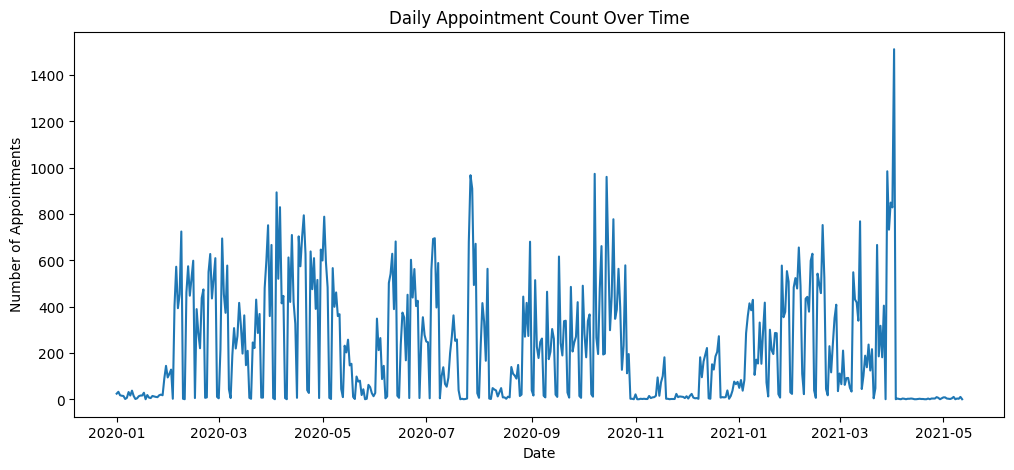

In [201]:
import matplotlib.pyplot as plt

# Plot time series
plt.figure(figsize=(12,5))
plt.plot(daily_appointments['appointment_date_continuous'],
         daily_appointments['appointment_count'])

plt.title("Daily Appointment Count Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Appointments")
plt.show()

In [202]:
# Time-based split

split_date = '2021-01-01'

ts_train = daily_appointments[daily_appointments['appointment_date_continuous'] < split_date]
ts_test = daily_appointments[daily_appointments['appointment_date_continuous'] >= split_date]

# Check
print("Train shape:", ts_train.shape)
print("Test shape:", ts_test.shape)

print("\nTrain range:",
      ts_train['appointment_date_continuous'].min(),
      "to",
      ts_train['appointment_date_continuous'].max())

print("\nTest range:",
      ts_test['appointment_date_continuous'].min(),
      "to",
      ts_test['appointment_date_continuous'].max())

Train shape: (366, 2)
Test shape: (132, 2)

Train range: 2020-01-01 00:00:00 to 2020-12-31 00:00:00

Test range: 2021-01-01 00:00:00 to 2021-05-12 00:00:00


In [203]:
# Create lag features

ts_train = ts_train.copy()
ts_test = ts_test.copy()

for lag in [1, 7, 14]:
    ts_train[f'lag_{lag}'] = ts_train['appointment_count'].shift(lag)
    ts_test[f'lag_{lag}'] = ts_test['appointment_count'].shift(lag)

In [204]:
# Drop NaN values created by lag
ts_train = ts_train.dropna()
ts_test = ts_test.dropna()

# Check
ts_train.head()

,appointment_date_continuous,appointment_count,lag_1,lag_7,lag_14
14,2020-01-15,17,14.0,32.0,25.0
15,2020-01-16,17,17.0,17.0,33.0
16,2020-01-17,29,17.0,38.0,18.0
17,2020-01-18,1,29.0,15.0,16.0
18,2020-01-19,19,1.0,2.0,15.0


In [205]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =========================
# 1. Add time features (keep if already added)
# =========================
ts_train = ts_train.copy()
ts_test = ts_test.copy()

ts_train['day_of_week'] = ts_train['appointment_date_continuous'].dt.dayofweek
ts_train['month'] = ts_train['appointment_date_continuous'].dt.month

ts_test['day_of_week'] = ts_test['appointment_date_continuous'].dt.dayofweek
ts_test['month'] = ts_test['appointment_date_continuous'].dt.month

# =========================
# 2. Features
# =========================
features = ['lag_1', 'lag_7', 'lag_14', 'day_of_week', 'month']

X_train_ts = ts_train[features]
X_test_ts = ts_test[features]

# 👉 LOG TRANSFORM TARGET
y_train_ts = np.log1p(ts_train['appointment_count'])
y_test_ts = ts_test['appointment_count']   # keep original for evaluation

# =========================
# 3. Train model
# =========================
rf_ts_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

rf_ts_model.fit(X_train_ts, y_train_ts)

# =========================
# 4. Predict (inverse transform)
# =========================
y_pred_log = rf_ts_model.predict(X_test_ts)
y_pred_ts = np.expm1(y_pred_log)   # convert back

# =========================
# 5. Evaluation
# =========================
mae = mean_absolute_error(y_test_ts, y_pred_ts)
rmse = np.sqrt(mean_squared_error(y_test_ts, y_pred_ts))
r2 = r2_score(y_test_ts, y_pred_ts)

# 👉 Better MAPE (ignore near-zero days)
mask = y_test_ts > 10
mape = np.mean(np.abs((y_test_ts[mask] - y_pred_ts[mask]) / y_test_ts[mask])) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("MAPE (filtered):", mape)

MAE: 131.21405986503328
RMSE: 239.66783525086836
R2 Score: 0.22428745084900437
MAPE (filtered): 69.89203134059669


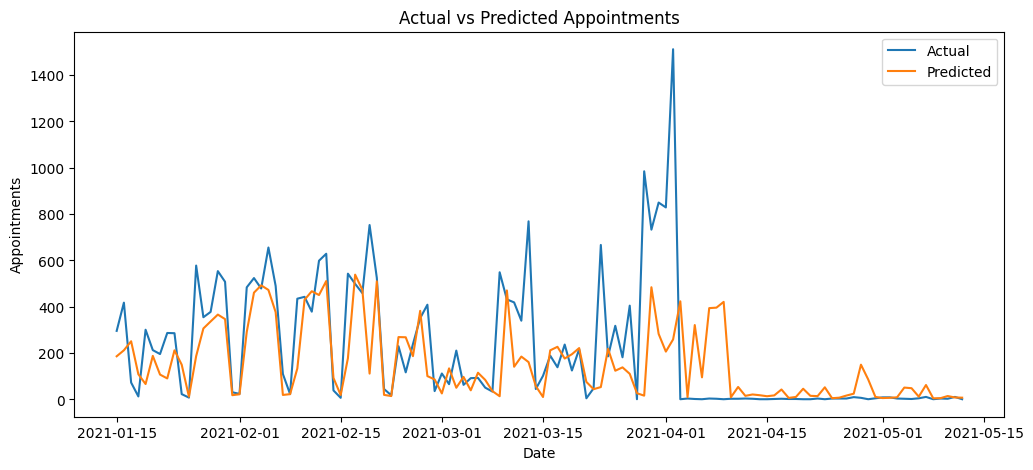

In [206]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(ts_test['appointment_date_continuous'], y_test_ts, label='Actual')
plt.plot(ts_test['appointment_date_continuous'], y_pred_ts, label='Predicted')

plt.title("Actual vs Predicted Appointments")
plt.xlabel("Date")
plt.ylabel("Appointments")
plt.legend()

plt.show()

In [207]:
import joblib

# =========================
# Save Classification Model
# =========================
joblib.dump(rf_model, "../models/no_show_model.pkl")

# Save Label Encoders (important for Streamlit input)
joblib.dump(le_dict, "../models/label_encoders.pkl")


# =========================
# Save Time Series Model
# =========================
joblib.dump(rf_ts_model, "../models/demand_forecast_model.pkl")

print("Models saved successfully!")

Models saved successfully!


In [208]:
!pip install lightgbm


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [209]:
ts_train.columns

Index(['appointment_date_continuous', 'appointment_count', 'lag_1', 'lag_7',
       'lag_14', 'day_of_week', 'month'],
      dtype='object')

In [210]:
df.columns

Index(['specialty', 'appointment_time', 'gender', 'no_show', 'disability',
       'place', 'appointment_shift', 'age', 'under_12_years_old',
       'over_60_years_old', 'patient_needs_companion', 'average_temp_day',
       'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before',
       'storm_day_before', 'rain_intensity', 'heat_intensity',
       'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism',
       'Handcap', 'Scholarship', 'SMS_received'],
      dtype='object')

In [211]:
# Convert date column
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])

# Create time-series dataset
ts = df.groupby('appointment_date_continuous').size().reset_index(name='appointment_count')

ts.head()

,appointment_date_continuous,appointment_count
0,2020-01-01,25
1,2020-01-02,33
2,2020-01-03,18
3,2020-01-04,16
4,2020-01-05,15


In [212]:
# Create lag features
ts['lag_1'] = ts['appointment_count'].shift(1)
ts['lag_7'] = ts['appointment_count'].shift(7)
ts['lag_14'] = ts['appointment_count'].shift(14)

# Time features
ts['day_of_week'] = ts['appointment_date_continuous'].dt.dayofweek
ts['month'] = ts['appointment_date_continuous'].dt.month

# Drop nulls
ts = ts.dropna()

ts.head()

,appointment_date_continuous,appointment_count,lag_1,lag_7,lag_14,day_of_week,month
14,2020-01-15,17,14.0,32.0,25.0,2,1
15,2020-01-16,17,17.0,17.0,33.0,3,1
16,2020-01-17,29,17.0,38.0,18.0,4,1
17,2020-01-18,1,29.0,15.0,16.0,5,1
18,2020-01-19,19,1.0,2.0,15.0,6,1


In [213]:
ts.columns

Index(['appointment_date_continuous', 'appointment_count', 'lag_1', 'lag_7',
       'lag_14', 'day_of_week', 'month'],
      dtype='object')

In [214]:
features = [
    'lag_1', 'lag_7', 'lag_14',
    'day_of_week', 'month',
    'average_temp_day', 'average_rain_day'
]

In [215]:
# Add simulated weather (for now)
import numpy as np

ts['average_temp_day'] = 25 + 5*np.sin(np.arange(len(ts)) * 2 * np.pi / 365)
ts['average_rain_day'] = np.random.choice([0,1,2,5,10], size=len(ts))

ts.head()

,appointment_date_continuous,appointment_count,lag_1,lag_7,lag_14,day_of_week,month,average_temp_day,average_rain_day
14,2020-01-15,17,14.0,32.0,25.0,2,1,25.000000,1
15,2020-01-16,17,17.0,17.0,33.0,3,1,25.086067,1
16,2020-01-17,29,17.0,38.0,18.0,4,1,25.172108,10
17,2020-01-18,1,29.0,15.0,16.0,5,1,25.258098,2
18,2020-01-19,19,1.0,2.0,15.0,6,1,25.344012,0


In [216]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [217]:
# Split
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

X_train = train[features]
y_train = train['appointment_count']

X_test = test[features]
y_test = test['appointment_count']

In [218]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [219]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model = XGBRegressor(n_estimators=200, learning_rate=0.05)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("R2:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))

R2: -0.1640024185180664
MAE: 216.87614080832176


In [220]:
import os
os.makedirs("models", exist_ok=True)

In [221]:
import joblib
joblib.dump(model, "models/demand_forecast_model.pkl")

['models/demand_forecast_model.pkl']

In [223]:
print(X_train.columns)

Index(['lag_1', 'lag_7', 'lag_14', 'day_of_week', 'month', 'average_temp_day',
       'average_rain_day'],
      dtype='object')
